<a href="https://colab.research.google.com/github/taibaabid/FlyRank_ML_Internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### 1. Ranked Actions + Reason Codes
This section converts raw performance metrics, trend directions, and commercial value signals into concrete editorial actions. Each action is backed by an explicit reason code so editorial teams understand why an item was prioritized.

In [27]:
# define action and reason code assignment logic
def assign_action_and_reason(row):
    # high-value decay (striking distance or high commercial value dropping)
    if row['trend_pct'] < -25 and (row['search_volume'] > 500 or row['cpc'] > 1.5 or row['position_tier'] == 'striking'):
        return 'Urgent Refresh', 'HIGH_VALUE_STRIKING_DECAY'

    # structural / intent issues (poor engagement or position > 20 despite high volume)
    elif row['avg_position'] > 20 and row['search_volume'] > 1000:
        return 'Structural Rewrite', 'HIGH_VOL_POOR_RANK'

    # natural aging decay (moderate decline on older content)
    elif row['trend_pct'] < -15 and row['days_since_last_update'] > 180:
        return 'Light Update', 'NATURAL_DECAY_AGING'

    # zero-volume / stale deadweight
    elif row['pageviews_90d'] < 10 and row['search_volume'] < 10 and row['days_since_last_update'] > 365:
        return 'Prune / Consolidate', 'LOW_VALUE_STALE'

    # stable performers
    else:
        return 'Monitor', 'STABLE_PERFORMANCE'

# apply categorization
df[['recommended_action', 'reason_code']] = df.apply(assign_action_and_reason, axis=1, result_type='expand')

# compute normalized priority score for ranking: value * absolute decay
value_score = np.log1p(df['search_volume']) * (1 + df['cpc'])
decay_severity = np.clip(np.abs(df['trend_pct']), 0, 100) / 100.0
df['priority_score'] = np.round(value_score * decay_severity, 3)

# filter queue to active recommendations (excluding passive monitor)
ranked_queue = df[df['recommended_action'] != 'Monitor'].sort_values(by='priority_score', ascending=False).reset_index(drop=True)

print(f"Total evaluated items: {len(df)}")
print(f"Actionable items in queue: {len(ranked_queue)}")
ranked_queue[['content_id', 'content_type', 'main_intent', 'recommended_action', 'reason_code', 'priority_score']].head(5)

Total evaluated items: 30000
Actionable items in queue: 5471


,content_id,content_type,main_intent,recommended_action,reason_code,priority_score
0,content_5b5e85993c2b,keyword article,informational,Urgent Refresh,HIGH_VALUE_STRIKING_DECAY,287.624
1,content_bd1cb333af49,keyword article,informational,Urgent Refresh,HIGH_VALUE_STRIKING_DECAY,264.332
2,content_3a4099af9765,keyword article,informational,Urgent Refresh,HIGH_VALUE_STRIKING_DECAY,168.171
3,content_f2e20dd8d68b,keyword article,informational,Urgent Refresh,HIGH_VALUE_STRIKING_DECAY,150.217
4,content_912484acf3be,keyword article,transactional,Urgent Refresh,HIGH_VALUE_STRIKING_DECAY,133.222


### 2. Intended Use and Limits

**Intended Use:**
* Decision-support queue for editorial and SEO content teams to prioritize monthly content maintenance sprints.
* Identifies statistical decay patterns and high-opportunity traffic retention targets.

**Limits & Boundaries:**
* **Non-Production Heuristic:** Model scores represent statistical trends, not editorial or qualitative evaluations.
* **No Quality Assessment:** The model cannot evaluate brand voice compliance, factual accuracy, legal constraints, or user sentiment.
* **External Factor Blindness:** Model does not account for algorithmic search engine core updates or competitor backlink campaigns.

### 3. Human Review & The No-Go List

**Human Review Checklist:**
1. Verify search intent alignment before executing structural rewrites.
2. Confirm factual and pricing accuracy on transactional/commercial articles.
3. Review internal linking structures before archiving or redirecting pages.

**The No-Go List (Strictly Disallowed Automations):**
* **No Automated Deletion / 404s:** Pruning must always involve human review and 301-redirect mapping.
* **No Unreviewed Generative Content Overwrites:** AI-generated refresh drafts must not be published directly without editorial sign-off.
* **No Automated Meta / Canonical Modification:** Canonical tag and indexation changes must remain strictly manual.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [28]:
# monitoring sanity check: calculate distribution of recommended actions
action_summary = df['recommended_action'].value_counts(normalize=True) * 100
print("Action Distribution (%):")
print(action_summary.round(2))

# define operational retrain triggers
retrain_triggers = {
    "distribution_shift_threshold_pct": 20.0,
    "min_evaluation_cadence_days": 30,
    "max_acceptable_decay_misclassification_pct": 15.0
}

Action Distribution (%):
recommended_action
Monitor                81.76
Urgent Refresh         17.42
Structural Rewrite      0.59
Light Update            0.22
Prune / Consolidate     0.01
Name: proportion, dtype: float64


**Retrain Triggers:**
* **Distribution Drift:** If any single action bucket expands or contracts by more than 20% month-over-month.
* **Cadence Trigger:** Full quarterly pipeline rerun to adapt to seasonal search trends.
* **Decay Drift:** If actual traffic recovery on refreshed pages diverges by >15% from predicted trajectories.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Ranked queue exported to: work/outputs/ranked_action_queue.csv


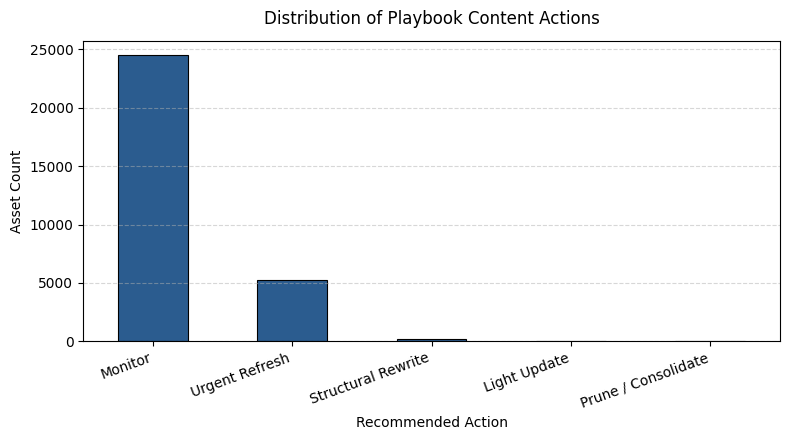

Figure saved to: work/figures/action_distribution.png
Summary metrics exported to: work/outputs/playbook_metrics.json


In [29]:
# export the ranked queue (excluded from git tracking by default)
export_cols = ['content_id', 'client_id', 'content_type', 'main_intent', 'recommended_action', 'reason_code', 'priority_score', 'search_volume', 'trend_pct']
ranked_queue[export_cols].to_csv(output_dir / "ranked_action_queue.csv", index=False)
print(f"Ranked queue exported to: {output_dir / 'ranked_action_queue.csv'}")

# generate and save visualization figure to work/figures/
fig, ax = plt.subplots(figsize=(8, 4.5))
action_counts = df['recommended_action'].value_counts()
action_counts.plot(kind='bar', ax=ax, color='#2b5c8f', edgecolor='black', linewidth=0.8)
ax.set_title("Distribution of Playbook Content Actions", fontsize=12, pad=12)
ax.set_ylabel("Asset Count", fontsize=10)
ax.set_xlabel("Recommended Action", fontsize=10)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

figure_path = figure_dir / "action_distribution.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Figure saved to: {figure_path}")

# export summary metrics JSON for research paper receipts
summary_metrics = {
    "total_assets_evaluated": int(len(df)),
    "actionable_queue_size": int(len(ranked_queue)),
    "urgent_refresh_count": int((df['recommended_action'] == 'Urgent Refresh').sum()),
    "structural_rewrite_count": int((df['recommended_action'] == 'Structural Rewrite').sum()),
    "light_update_count": int((df['recommended_action'] == 'Light Update').sum()),
    "prune_consolidate_count": int((df['recommended_action'] == 'Prune / Consolidate').sum()),
    "monitor_count": int((df['recommended_action'] == 'Monitor').sum())
}

metrics_path = output_dir / "playbook_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(summary_metrics, f, indent=2)

print(f"Summary metrics exported to: {metrics_path}")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.